In [1]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 6.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 38.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 79.0 MB/s eta 0:00:00:00:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92


In [2]:
from roboflow import Roboflow

rf = Roboflow(api_key="bNzNpN73OxOtyGelagV6")
project = rf.workspace("mohamed-traore-2ekkp").project("face-detection-mik1i")
version = project.version(25)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Face-Detection-25 in yolov8:: 100%|██████████| 8552/8552 [00:00<00:00, 9077.33it/s] 


In [3]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.7 MB/s eta 0:00:00a 0:00:01


In [4]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

results = model.train(
    data = f'{dataset.location}/data.yaml', 
    epochs = 100,
    patience = 25,
    imgsz = 640,
    batch=32,  
    project='kaggle_yolo',
    name='v8s_run'
)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Face-Detection-25/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5

Testing on image: Movie-on-2-18-25-at-8_25-PM_mov-0148_jpg.rf.53ac3fabbc77b0d4739a3dd48bf8e4ab.jpg

image 1/1 /kaggle/working/Face-Detection-25/test/images/Movie-on-2-18-25-at-8_25-PM_mov-0148_jpg.rf.53ac3fabbc77b0d4739a3dd48bf8e4ab.jpg: 640x640 2 faces, 16.1ms
Speed: 1.7ms preprocess, 16.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


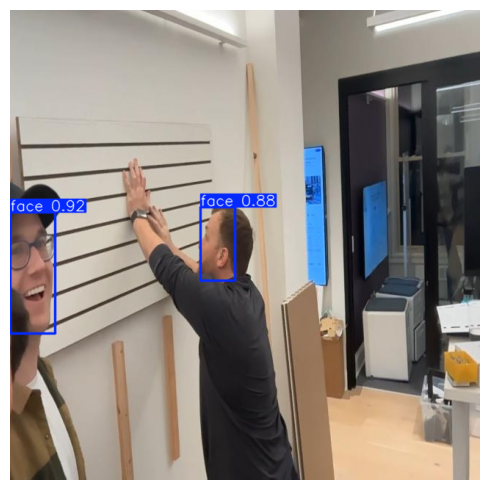

In [13]:
import os
import random
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

model_path = '/kaggle/working/runs/detect/kaggle_yolo/v8s_run/weights/best.pt'
trained_model = YOLO(model_path)

test_dir = f"{dataset.location}/test/images/"
all_test_images = os.listdir(test_dir)
random_image_name = random.choice(all_test_images)
test_image_path = os.path.join(test_dir, random_image_name)

print(f"Testing on image: {random_image_name}")

results = trained_model.predict(source=test_image_path, conf=0.5)

result = results[0]
plotted_image = result.plot() 
plotted_image_rgb = cv2.cvtColor(plotted_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(plotted_image_rgb)
plt.axis('off')
plt.tight_layout()
plt.show()